## 1. Setup

### 1.0 Google Drive Sync
Pode ignorar essa seção se não estiver usando Google Colab

In [1]:
# Adicionar o conteúdo do drive no caminho do sistema

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!dir

/content/drive/Othercomputers/Meu laptop/projetos-if702/projeto-churn
0_preprocessamento.ipynb  datasets     __pycache__     stab.py
1_MLP.ipynb		  KAN.ipynb    results	       TabKAN.ipynb
2_XGBoost.ipynb		  ml_utils.py  searches        TabPFN.ipynb
6_Mitra.ipynb		  models       split_churn.py
churn_preprocessing.py	  plots        STab.ipynb


In [3]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [4]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

### 1.1 Importar Libs

In [5]:
!pip install optuna mljar-scikit-plot

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.1 MB/s eta 0:00:00
  Created wheel for mljar-scikit-plot: filename=mljar_scikit_plot-0.3.12-py3-none-any.whl size=32014 sha256=96367b6f7857e34c0e38af6740aae126e6ec2a43d00be0dca9569805e808936f
  Stored in directory: /root/.cache/pip/wheels/24/e5/1e/3b952f43ebd4bd0a6983c835daa4e226f2eeee4080e5b1ceb9
Successfully built mljar-scikit-plot


In [6]:
import importlib
import ml_utils
import churn_preprocessing

importlib.invalidate_caches()
importlib.reload(ml_utils)
importlib.reload(churn_preprocessing)

<module 'churn_preprocessing' from '/content/drive/Othercomputers/Meu laptop/projetos-if702/projeto-churn/churn_preprocessing.py'>

In [7]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import optuna.visualization as optuna_vis
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import torch
import json
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,)
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
 )

from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

## CPU ou GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

Bibliotecas importadas com sucesso!
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Device: CUDA


### 1.2 Configuração do Modelo

In [8]:
from stab import STabClassifier

MODEL_NAME = "STab"
MODEL_CLASS = STabClassifier

n_trials = 100
scoring_metric = 'f1'
loss_fn = get_loss_fn('bce_with_logits')

training_epochs_per_trial = 10000
early_stopping_patience = 15
early_stopping_delta = 0.001



## 2. Carregamento dos Dados

In [9]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

# Manter nomes usados no restante do notebook
X_train_scaled = X_train
X_val_scaled = X_val
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())


=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [10]:
print("\nPrimeiras linhas do dataset de treino:")
train_data.head()


Primeiras linhas do dataset de treino:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Busca de Hiperparâmetros

### 3.0 Sampling Para Busca
Pode escolher não usar também (ou usar frac=1.0)

In [11]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


Dataset original de treino: 5,174 amostras
Amostra para busca de hiperparâmetros: 259 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {0: 130, 1: 129}
Original: {0: 2587, 1: 2587}


### 3.1 Configs da Busca Optuna

In [12]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.7, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

n_trials = 100
scoring_metric = 'ks'

loss_fn = FocalLoss(alpha=0.7, gamma=2.0)

early_stopping_patience = 15
early_stopping_delta = 0.001
training_epochs_per_trial = 50

### 3.2 Definção do Espaço de Hiperparâmetros


In [14]:
hidden_layer_sizes = [
    # 2 camadas
    (1024, 256),
    (1024, 512),
    (1536, 384),
    (2048, 256),
    # Variações de 3 camadas baseadas na melhor
    (1024, 384, 128),
    (1024, 384, 256),
    (1024, 512, 128),
    (1024, 512, 256),
    (1536, 384, 128),
    (1536, 512, 128),
    (2048, 384, 128),
    (2048, 512, 256),
    # 4 camadas
    (1024, 512, 256, 128),
    (1536, 512, 256, 128),
]

input_features_count = X_train_scaled.shape[1]

param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "input_dim": {"type": "categorical", "values": [input_features_count]},
        "num_layers": {"type": "categorical", "values": [1]},
        "num_heads": {"type": "categorical", "values": [4, 8]},
        "embed_dim": {"type": "categorical", "values": [64, 128]},
        "dropout_rate": {"type": "categorical", "values": [0.1, 0.3, 0.5, 0.7]},
        "dropconnect_rate": {"type": "categorical", "values": [0.5, 0.7]},
        "learning_rate": {"type": "categorical", "values": [1e-4, 2e-4]},
        "batch_size": {"type": "categorical", "values": [128, 256]},
        "optimizer": {"type": "categorical", "values": ["AdamW"]},
        "weight_decay": {"type": "categorical", "values": [1e-4]},
        "lr_scheduler": {"type": "categorical", "values": ["ReduceLROnPlateau"]}
    },
)

print_hyperparameter_space(param_space)

Hyperparameter space:
- input_dim: type=categorical, values=[19]
- num_layers: type=categorical, values=[1]
- num_heads: type=categorical, values=[4, 8]
- embed_dim: type=categorical, values=[64, 128]
- dropout_rate: type=categorical, values=[0.1, 0.3, 0.5, 0.7]
- dropconnect_rate: type=categorical, values=[0.5, 0.7]
- learning_rate: type=categorical, values=[0.0001, 0.0002]
- batch_size: type=categorical, values=[128, 256]
- optimizer: type=categorical, values=['AdamW']
- weight_decay: type=categorical, values=[0.0001]
- lr_scheduler: type=categorical, values=['ReduceLROnPlateau']


### 3.3 Executar Busca de Hiperparâmetros

In [15]:

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Trials: {n_trials}")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")
print(f"Hiperparâmetros no espaço: {list(param_space.keys())}")

direction = "minimize" if scoring_metric in {"val_loss", "loss"} else "maximize"
study = run_optuna_search(
    model_class=MODEL_CLASS,
    space=param_space,
    X_train=X_sample,
    y_train=y_sample,
    X_val=X_val,
    y_val=y_val,
    n_trials=n_trials,
    direction=direction,
    scoring_metric=scoring_metric,
    device=device,
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta,
    loss_fn=loss_fn,
 )

print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score ({scoring_metric}): {study.best_value:.6f}")

[I 2026-07-02 20:19:56,890] A new study created in memory with name: no-name-95df2382-1b4c-4823-889c-def26654eca7


=== BUSCA DE HIPERPARÂMETROS - STab ===
Iniciando busca de hiperparâmetros para STab...
Trials: 100
Usando amostra de 259 exemplos

Hiperparâmetros no espaço: ['input_dim', 'num_layers', 'num_heads', 'embed_dim', 'dropout_rate', 'dropconnect_rate', 'learning_rate', 'batch_size', 'optimizer', 'weight_decay', 'lr_scheduler']


[I 2026-07-02 20:20:17,006] Trial 0 finished with value: 0.4880123743232792 and parameters: {'input_dim': 19, 'num_layers': 1, 'num_heads': 8, 'embed_dim': 128, 'dropout_rate': 0.3, 'dropconnect_rate': 0.5, 'learning_rate': 0.0002, 'batch_size': 128, 'optimizer': 'AdamW', 'weight_decay': 0.0001, 'lr_scheduler': 'ReduceLROnPlateau'}. Best is trial 0 with value: 0.4880123743232792.
[I 2026-07-02 20:20:19,410] Trial 1 finished with value: 0.4609435421500387 and parameters: {'input_dim': 19, 'num_layers': 1, 'num_heads': 8, 'embed_dim': 64, 'dropout_rate': 0.1, 'dropconnect_rate': 0.7, 'learning_rate': 0.0002, 'batch_size': 128, 'optimizer': 'AdamW', 'weight_decay': 0.0001, 'lr_scheduler': 'ReduceLROnPlateau'}. Best is trial 0 with value: 0.4880123743232792.
[I 2026-07-02 20:20:23,669] Trial 2 finished with value: 0.4709976798143851 and parameters: {'input_dim': 19, 'num_layers': 1, 'num_heads': 8, 'embed_dim': 64, 'dropout_rate': 0.1, 'dropconnect_rate': 0.5, 'learning_rate': 0.0001, 'bat


--- RESULTADOS STab ---
Melhores hiperparâmetros encontrados:
  input_dim: 19
  num_layers: 1
  num_heads: 8
  embed_dim: 64
  dropout_rate: 0.7
  dropconnect_rate: 0.5
  learning_rate: 0.0001
  batch_size: 256
  optimizer: AdamW
  weight_decay: 0.0001
  lr_scheduler: ReduceLROnPlateau

Melhor score (ks): 0.513534


### 3.4 Visualizar Histórico da Busca

In [16]:
# Registro de Desempenho - plotar evolução da busca
optuna_vis.plot_param_importances(study)

In [17]:
optuna_vis.plot_optimization_history(study, target_name=scoring_metric)


In [18]:
optuna_vis.plot_parallel_coordinate(study, params=list(param_space.keys()), target_name=scoring_metric)

In [19]:

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS - {MODEL_NAME} ===")

trials_df = study.trials_dataframe()
if "state" in trials_df.columns:
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]
sorted_df = trials_df.sort_values("value", ascending=(direction == "minimize"))

print(f"\nTop configurações (de {len(sorted_df)} trials completos):")
print(sorted_df.head(10).to_string(index=False))

if not sorted_df.empty:
    print(f"\nEstatísticas dos scores encontrados:")
    print(f"  Média: {sorted_df['value'].mean():.4f}")
    print(f"  Mediana: {sorted_df['value'].median():.4f}")
    print(f"  Desvio padrão: {sorted_df['value'].std():.4f}")
    print(f"  Min: {sorted_df['value'].min():.4f}")
    print(f"  Max: {sorted_df['value'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - STab ===

Top configurações (de 100 trials completos):
 number    value             datetime_start          datetime_complete               duration  params_batch_size  params_dropconnect_rate  params_dropout_rate  params_embed_dim  params_input_dim  params_learning_rate params_lr_scheduler  params_num_heads  params_num_layers params_optimizer  params_weight_decay    state
     24 0.513534 2026-07-02 20:21:51.504094 2026-07-02 20:21:56.496781 0 days 00:00:04.992687                128                      0.5                  0.7                64                19                0.0001   ReduceLROnPlateau                 8                  1            AdamW               0.0001 COMPLETE
     17 0.513534 2026-07-02 20:21:21.959279 2026-07-02 20:21:27.121573 0 days 00:00:05.162294                128                      0.5                  0.7                64                19                0.0001   ReduceLROnPlateau                 8        

## 4. Salvar Resultados de Busca

In [20]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

trials_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_trials.csv")
best_params_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_best.json")

trials_df.to_csv(trials_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

print("Resultados da busca salvos:")
print(trials_path)
print(best_params_path)

Resultados da busca salvos:
searches/stab_optuna_trials.csv
searches/stab_optuna_best.json


In [21]:
# Rodar essa célula mesmo que não carregue os resultados da busca
# para evitar erro na seção 6
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [22]:
if os.path.exists(trials_path):
    loaded_trials_df = pd.read_csv(trials_path)
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        loaded_best_params = json.load(f)

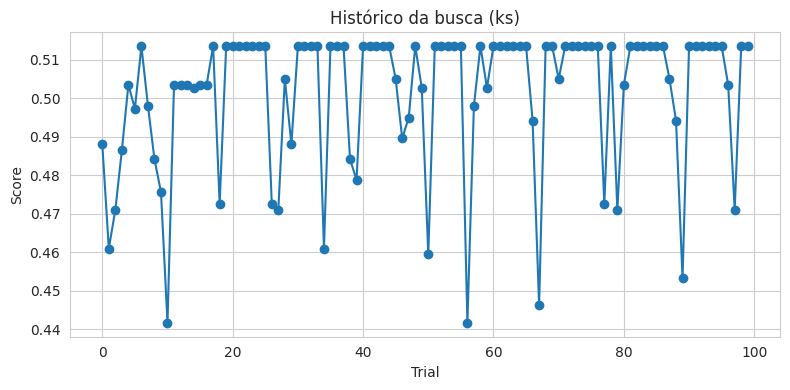

In [23]:
# Plotar a história da busca a partir dos resultados carregados
if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
    plot_df = loaded_trials_df.sort_values("number") if "number" in loaded_trials_df.columns else loaded_trials_df
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["value"].values, marker="o")
    plt.title(f"Histórico da busca ({scoring_metric})")
    plt.xlabel("Trial")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

## 6. Definir Melhores Params e Score de Busca

In [24]:
# Definir Melhores Parâmetros para Uso Posterior
if loaded_best_params is not None:
    best_params = loaded_best_params
    if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
        best_score = (
            loaded_trials_df["value"].min()
            if direction == "minimize"
            else loaded_trials_df["value"].max()
        )
    else:
        best_score = study.best_value
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor score carregado: {best_score:.6f}")
else:
    best_params = study.best_params
    best_score = study.best_value
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor score da busca atual: {best_score:.6f}")

if isinstance(best_params.get("hidden_layer_sizes"), str):
    best_params["hidden_layer_sizes"] = eval(best_params["hidden_layer_sizes"])

✅ Usando parâmetros carregados: {'input_dim': 19, 'num_layers': 1, 'num_heads': 8, 'embed_dim': 64, 'dropout_rate': 0.7, 'dropconnect_rate': 0.5, 'learning_rate': 0.0001, 'batch_size': 256, 'optimizer': 'AdamW', 'weight_decay': 0.0001, 'lr_scheduler': 'ReduceLROnPlateau'}
✅ Melhor score carregado: 0.513534


## 7. Treinar Modelo Final e Salvar

In [25]:
import torch.optim as optim
from ml_utils import train_model

# 1. Conta colunas
input_features_count = X_train_scaled.shape[1]

# 2. Filtrar parâmetros que não pertencem ao __init__ do modelo
# Parâmetros de treino que devem ser removidos do dicionário de inicialização do STabClassifier
train_params_keys = ['optimizer', 'lr_scheduler', 'batch_size', 'learning_rate', 'weight_decay']
model_params = {k: v for k, v in best_params.items() if k not in train_params_keys}

# 3. Criar o modelo
best_model = MODEL_CLASS(**model_params, random_state=RANDOM_STATE_MODEL)

# 4. Configurar otimizador
optimizer = optim.AdamW(best_model.parameters(),
                        lr=best_params.get("learning_rate", 1e-3),
                        weight_decay=best_params.get("weight_decay", 1e-4))

# 5. Treinar
train_results = train_model(
    model=best_model,
    X_train=X_train_scaled,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    batch_size=best_params.get("batch_size", 128),
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta
)

In [26]:
# Salvar o modelo treinado com os melhores hiperparâmetros
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)

print(f" Model saved to: {model_path}")

 Model saved to: models/stab_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [27]:
# Carregar modelo (Opcional)
loaded_model = load(model_path)

In [28]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train

X_val_eval = X_val_scaled
y_val_eval = y_val

X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model, X_train_eval, y_train_eval, device=device
)
val_metrics, y_val_pred, y_val_scores = evaluate_model(
    best_model, X_val_eval, y_val_eval, device=device
)
test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model, X_test_eval, y_test_eval, device=device
)

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - STab ===

Avaliando: STab


### 8.1 Classification Report

In [29]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1294
           1       0.51      0.80      0.62       468

    accuracy                           0.74      1762
   macro avg       0.71      0.76      0.71      1762
weighted avg       0.80      0.74      0.75      1762



KS Statistic: 0.5196


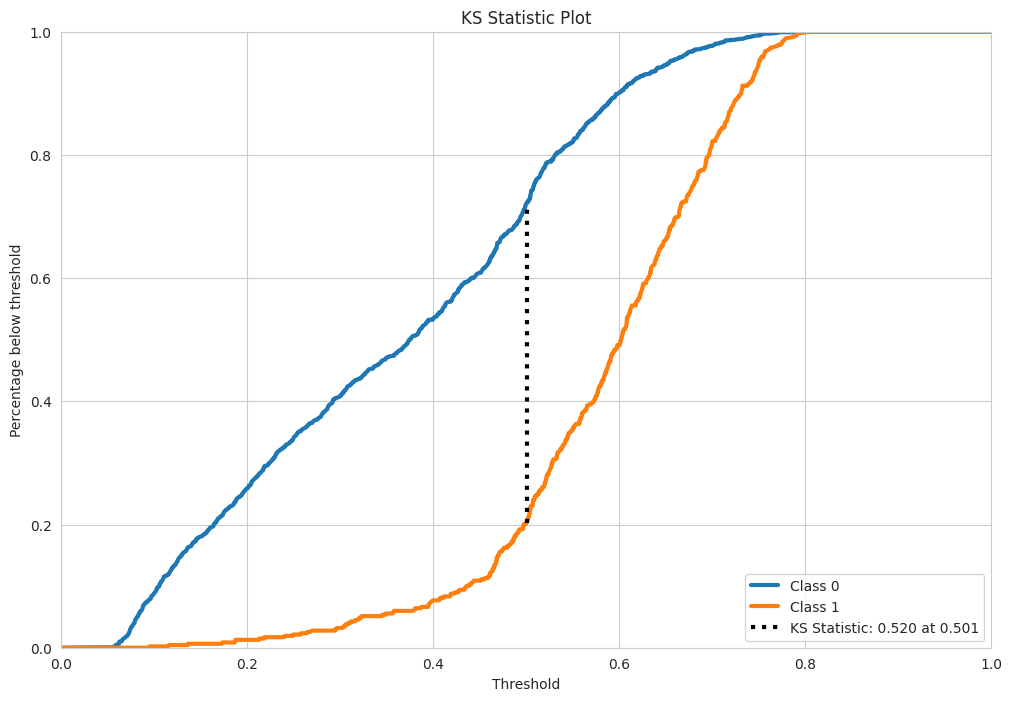

In [30]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)



### 8.2 Visualize Confusion Matrix

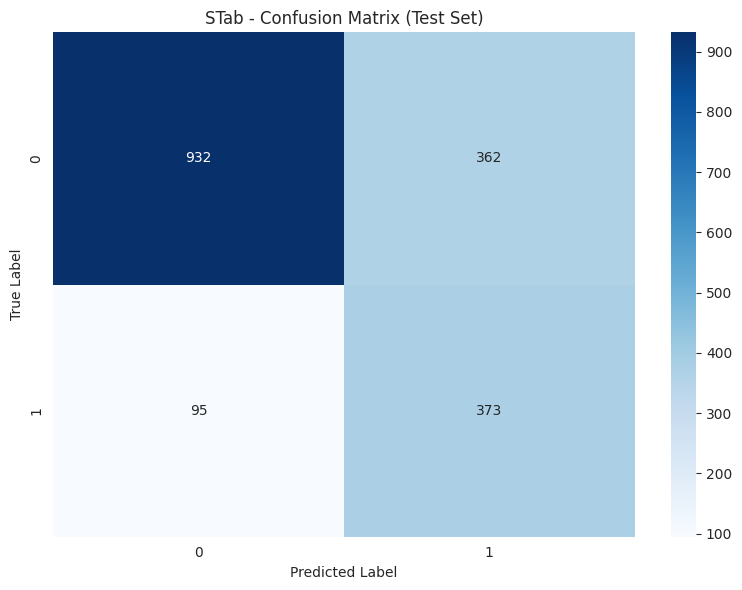

In [31]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [32]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL STab ---
Score da busca: 0.513534
KS Statistic Teste: 0.5196
AUC-ROC Teste: 0.8361
F1-Score Teste: 0.6201
Acurácia Teste: 0.7406
Precisão Teste: 0.5075
Recall Teste: 0.7970
Resultados salvos em: results/
Arquivo final: results/stab_final_results.json
